# 00-01 Barcelona vs Real Madrid：进入进攻三区后发生了什么？

**问题：** 两队怎样进入进攻三区？一次控球首次进入后，有多大概率到达禁区、形成射门并产生 xG？这种差异是否随比分状态改变？

**分析单位：** 一次起点满足 `x < 80`、终点满足 `x >= 80` 的 Pass 或 Carry 事件。

**预期产物：** 事件级进入图、possession 级结果图和比分状态对照。图只能描述这场比赛中的记录，不能单独证明球队的稳定风格或战术原因。

## 学习路径

1. 读取一场比赛的原始 events JSON。
2. 把不同嵌套结构的 Pass 和 Carry 整理成统一的进入事件表。
3. 按球队、方式、传球高度和球员汇总。
4. 在 StatsBomb 球场坐标上画出每次进入。
5. 每次 possession 只保留第一次成功进入，并检查后续禁区行动、射门和 xG。
6. 按比分状态比较结果，并区分指标结果、足球解释与待验证假设。

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from mplsoccer import Pitch

from football_analytics import get_open_data_root, get_project_root

MATCH_ID = 3773585
SOURCE_COMMIT = "b0bc9f22dd77c206ddedc1d742893b3bbe64baec"
PROJECT_ROOT = get_project_root()
OPEN_DATA_ROOT = get_open_data_root(PROJECT_ROOT)
EVENTS_PATH = OPEN_DATA_ROOT / "data" / "events" / f"{MATCH_ID}.json"

with EVENTS_PATH.open() as handle:
    events = json.load(handle)

len(events), EVENTS_PATH.relative_to(PROJECT_ROOT), SOURCE_COMMIT

(4213,
 PosixPath('data/external/statsbomb-open-data/data/events/3773585.json'),
 'b0bc9f22dd77c206ddedc1d742893b3bbe64baec')

## 1. 建立进入事件表

`Pass` 的终点位于 `pass.end_location`，`Carry` 的终点位于 `carry.end_location`。StatsBomb 的 `Dribble` 表示一次过人尝试，不提供这类持续移动的终点，因此这里使用 Carry 表示持球推进。

成功传球没有 `pass.outcome` 字段。我们保留 `play_pattern` 和 `pass_type`，以便之后区分常规进攻、界外球和定位球来源。

In [2]:
entry_rows: list[dict[str, object]] = []

for event in events:
    method = event["type"]["name"]
    start = event.get("location")
    if method not in {"Pass", "Carry"} or start is None:
        continue

    detail = event[method.lower()]
    end = detail.get("end_location")
    if end is None or not start[0] < 80 <= end[0]:
        continue
    if method == "Pass" and detail.get("outcome") is not None:
        continue

    entry_rows.append(
        {
            "event_id": event["id"],
            "event_index": event["index"],
            "possession": event["possession"],
            "minute": event["minute"],
            "team": event["team"]["name"],
            "player": event.get("player", {}).get("name"),
            "method": method,
            "play_pattern": event["play_pattern"]["name"],
            "pass_type": detail.get("type", {}).get("name") if method == "Pass" else None,
            "pass_height": detail.get("height", {}).get("name") if method == "Pass" else None,
            "length": detail.get("length", math.dist(start, end)),
            "start_x": start[0],
            "start_y": start[1],
            "end_x": end[0],
            "end_y": end[1],
        }
    )

entries = pd.DataFrame(entry_rows)
entries.head(8)

,event_id,event_index,possession,minute,team,player,method,play_pattern,pass_type,pass_height,length,start_x,start_y,end_x,end_y
0,31509e6a-d5b1-4a94-a47b-c77d9492c1c4,127,3,2,Barcelona,Lionel Andrés Messi Cuccittini,Pass,Regular Play,NaN,Low Pass,32.088783,70.5,51.1,91.8,75.1
1,84b89d6a-8952-4d07-93e0-881f462e0ec1,183,7,3,Barcelona,Lionel Andrés Messi Cuccittini,Carry,Regular Play,NaN,NaN,4.716991,76.5,40.9,80.5,38.4
2,07c22583-e3ac-473d-ba43-89e923e4b55b,242,10,3,Real Madrid,Carlos Henrique Casimiro,Pass,From Keeper,NaN,High Pass,48.325665,44.1,45.9,83.2,17.5
3,74e2e017-da8e-4c91-ba74-e1e58e4fa39a,285,10,4,Real Madrid,Karim Benzema,Carry,From Keeper,NaN,NaN,16.348700,69.0,67.8,84.8,63.6
4,ee6e8929-5336-40cb-8321-b59a3eaab9b8,331,12,6,Real Madrid,Karim Benzema,Carry,Regular Play,NaN,NaN,20.412006,72.7,14.7,93.1,15.4
5,a26559f0-d5f9-474c-be25-c2ad857a6776,352,12,6,Real Madrid,Raphaël Varane,Pass,Regular Play,NaN,High Pass,53.976753,57.8,47.1,94.8,7.8
6,cb049c3e-6595-47fd-9b72-c86fc32b9361,385,14,7,Barcelona,Lionel Andrés Messi Cuccittini,Pass,From Free Kick,NaN,High Pass,46.536976,68.6,9.3,112.3,25.3
7,a667bd52-cbc8-4ca4-96d5-306adb14339d,426,17,9,Barcelona,Sergio Busquets i Burgos,Pass,Regular Play,NaN,Ground Pass,15.061541,69.3,29.8,83.2,35.6


In [3]:
assert len(entries) == 117
assert set(entries["method"]) == {"Pass", "Carry"}
assert entries["event_id"].is_unique
assert entries["start_x"].lt(80).all()
assert entries["end_x"].ge(80).all()

pd.Series(
    {
        "source_events": len(events),
        "final_third_entries": len(entries),
        "teams": entries["team"].nunique(),
        "players": entries["player"].nunique(),
    },
    name="data fact",
).to_frame()

,data fact
source_events,4213
final_third_entries,117
teams,2
players,24


上面的断言检查了本课定义，而不是验证比赛表现：每行必须是唯一事件、起点在三区外、终点在三区内。

In [4]:
method_counts = (
    pd.crosstab(entries["team"], entries["method"])
    .reindex(columns=["Pass", "Carry"], fill_value=0)
)
method_counts["Total"] = method_counts.sum(axis=1)

pass_entries = entries.loc[entries["method"] == "Pass"].copy()
height_order = ["Ground Pass", "Low Pass", "High Pass"]
height_counts = (
    pd.crosstab(pass_entries["team"], pass_entries["pass_height"])
    .reindex(columns=height_order, fill_value=0)
)
pass_length_summary = pass_entries.groupby("team")["length"].agg(
    count="size", median="median", mean="mean"
).round(2)

method_counts, height_counts, pass_length_summary

(method       Pass  Carry  Total
 team                           
 Barcelona      40     23     63
 Real Madrid    34     20     54,
 pass_height  Ground Pass  Low Pass  High Pass
 team                                         
 Barcelona             33         5          2
 Real Madrid           22         2         10,
              count  median   mean
 team                             
 Barcelona       40   19.28  22.38
 Real Madrid     34   21.00  26.38)

## 2. 球队层面的方式与高度

左图比较进入次数和方式；右图只看成功传球，并拆分 Ground、Low、High。原始数量会受到控球和比赛状态影响，因此这里先描述，不直接称为球队风格。

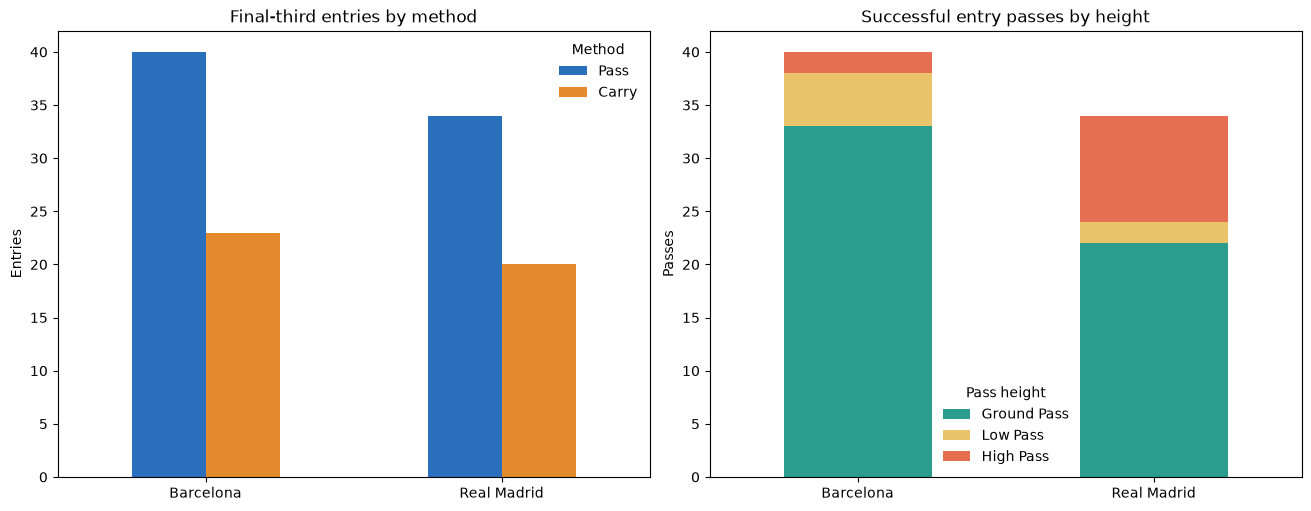

In [5]:
team_order = ["Barcelona", "Real Madrid"]
method_colors = {"Pass": "#2A6FBB", "Carry": "#E38B2C"}
height_colors = {
    "Ground Pass": "#2A9D8F",
    "Low Pass": "#E9C46A",
    "High Pass": "#E76F51",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
method_counts.loc[team_order, ["Pass", "Carry"]].plot.bar(
    ax=axes[0], color=[method_colors["Pass"], method_colors["Carry"]], rot=0
)
axes[0].set(title="Final-third entries by method", xlabel="", ylabel="Entries")
axes[0].legend(title="Method", frameon=False)

height_counts.loc[team_order, height_order].plot.bar(
    ax=axes[1], stacked=True, color=[height_colors[name] for name in height_order], rot=0
)
axes[1].set(title="Successful entry passes by height", xlabel="", ylabel="Passes")
axes[1].legend(title="Pass height", frameon=False)
plt.show()

## 3. 哪些球员完成进入？

每队选取进入次数最多的五名球员，并在同一条形中拆分 Pass 和 Carry。这里衡量的是这场比赛中的事件贡献，不等同于球员能力。

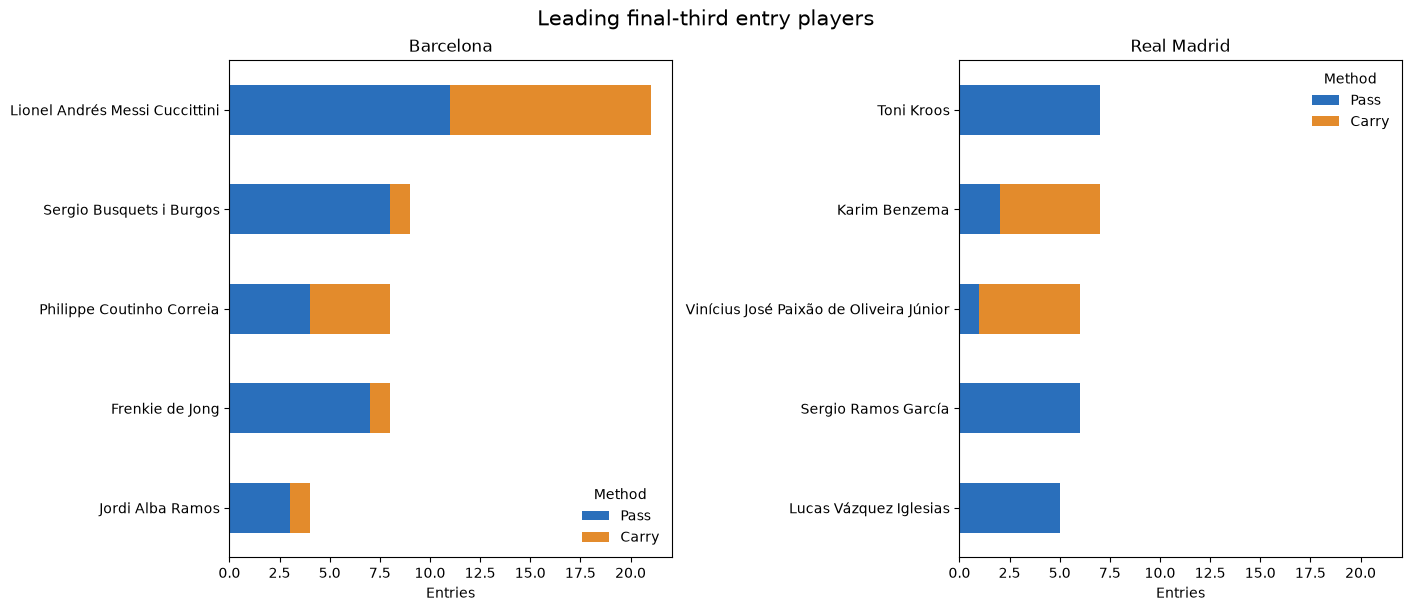

In [6]:
player_method = (
    entries.groupby(["team", "player", "method"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Pass", "Carry"], fill_value=0)
)
player_method["Total"] = player_method.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharex=True)
for ax, team in zip(axes, team_order, strict=True):
    top = player_method.loc[team].nlargest(5, "Total").sort_values("Total")
    top[["Pass", "Carry"]].plot.barh(
        ax=ax, stacked=True, color=[method_colors["Pass"], method_colors["Carry"]]
    )
    ax.set(title=team, xlabel="Entries", ylabel="")
    ax.legend(title="Method", frameon=False)
fig.suptitle("Leading final-third entry players", fontsize=15)
plt.show()

## 4. 进入发生在哪里？

箭头起点在 `x < 80`，终点在阴影表示的进攻三区。颜色表示 Pass 或 Carry。大量重叠本身也是信息：下一步可以按路线、比赛时间或进攻来源继续拆分，而不是只美化图形。

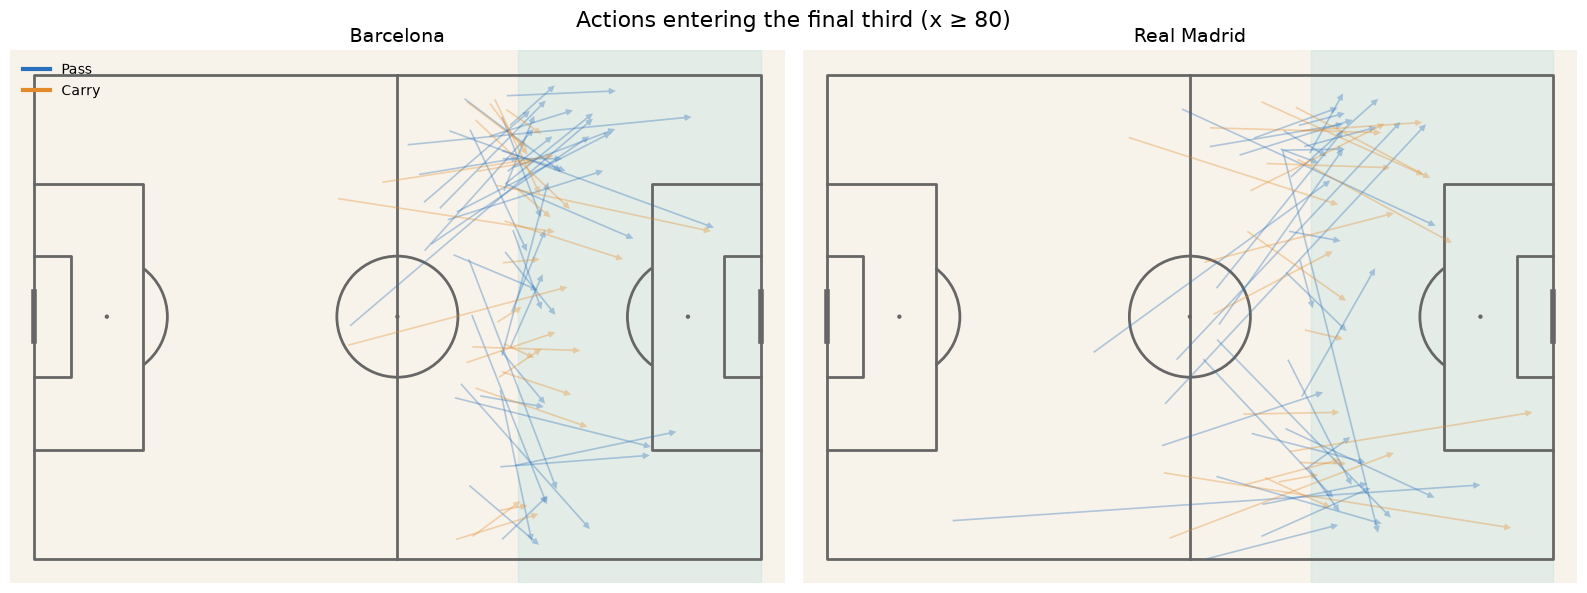

In [7]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#F7F3EA", line_color="#666666")
fig, axes = pitch.draw(ncols=2, figsize=(16, 6), constrained_layout=True)

for ax, team in zip(axes, team_order, strict=True):
    ax.axvspan(80, 120, color="#A8DADC", alpha=0.25, zorder=0)
    for method in ["Pass", "Carry"]:
        subset = entries.loc[(entries["team"] == team) & (entries["method"] == method)]
        pitch.arrows(
            subset["start_x"], subset["start_y"], subset["end_x"], subset["end_y"],
            ax=ax, color=method_colors[method], alpha=0.35,
            width=1.2, headwidth=4, headlength=4,
        )
    ax.set_title(team, fontsize=14)

legend = [
    Line2D([0], [0], color=method_colors["Pass"], lw=3, label="Pass"),
    Line2D([0], [0], color=method_colors["Carry"], lw=3, label="Carry"),
]
axes[0].legend(handles=legend, loc="upper left", frameon=False)
fig.suptitle("Actions entering the final third (x ≥ 80)", fontsize=16)
plt.show()

## 5. 从进入事件转向 possession 结果

同一次控球可能多次退出并重新进入进攻三区，因此117个事件不是117个独立进攻机会。这里按 StatsBomb `possession` 分组，每次控球只保留第一次成功进入。

后续结果分成两个并列问题：球队是否在同一次控球中记录到禁区内行动，以及是否形成射门。二者不是严格漏斗，因为球队可能从禁区外直接射门。xG 和进球只统计首次进入之后、同一次控球内的射门。

In [8]:
events_by_possession: dict[int, list[dict[str, object]]] = {}
score_before_event: dict[int, dict[str, int]] = {}
score = {team: 0 for team in team_order}

for event in sorted(events, key=lambda item: item["index"]):
    events_by_possession.setdefault(event["possession"], []).append(event)
    score_before_event[event["index"]] = score.copy()
    is_goal = event["type"]["name"] == "Shot" and event["shot"]["outcome"]["name"] == "Goal"
    if is_goal:
        score[event["team"]["name"]] += 1

first_entries = entries.sort_values("event_index").drop_duplicates("possession")
possession_rows: list[dict[str, object]] = []

def inside_box(location: list[float] | None) -> bool:
    return bool(location and location[0] >= 102 and 18 <= location[1] <= 62)


def event_reaches_box(event: dict[str, object]) -> bool:
    if inside_box(event.get("location")):
        return True
    event_type = event["type"]["name"]
    if event_type not in {"Pass", "Carry"}:
        return False
    detail = event[event_type.lower()]
    if event_type == "Pass" and detail.get("outcome") is not None:
        return False
    return inside_box(detail.get("end_location"))


for entry in first_entries.itertuples(index=False):
    possession_events = events_by_possession[entry.possession]
    later_events = [event for event in possession_events if event["index"] >= entry.event_index]
    attacking_events = [
        event for event in later_events if event.get("team", {}).get("name") == entry.team
    ]
    reached_box = any(event_reaches_box(event) for event in attacking_events)
    shots = [event for event in attacking_events if event["type"]["name"] == "Shot"]
    opponent = next(team for team in team_order if team != entry.team)
    entry_score = score_before_event[entry.event_index]
    score_state = (
        "Level"
        if entry_score[entry.team] == entry_score[opponent]
        else "Leading"
        if entry_score[entry.team] > entry_score[opponent]
        else "Trailing"
    )
    possession_rows.append(
        {
            "possession": entry.possession,
            "team": entry.team,
            "entry_minute": entry.minute,
            "entry_player": entry.player,
            "entry_method": entry.method,
            "entry_height": entry.pass_height,
            "play_pattern": entry.play_pattern,
            "score_state": score_state,
            "reached_box": reached_box,
            "has_shot": bool(shots),
            "xg": sum(shot["shot"]["statsbomb_xg"] for shot in shots),
            "goal": any(shot["shot"]["outcome"]["name"] == "Goal" for shot in shots),
        }
    )

possession_outcomes = pd.DataFrame(possession_rows)
assert len(possession_outcomes) == 78
assert possession_outcomes["possession"].is_unique
assert possession_outcomes.groupby("team").size().to_dict() == {
    "Barcelona": 44,
    "Real Madrid": 34,
}
assert possession_outcomes["reached_box"].sum() == 41
assert possession_outcomes["has_shot"].sum() == 17
possession_outcomes.head()

,possession,team,entry_minute,entry_player,entry_method,entry_height,play_pattern,score_state,reached_box,has_shot,xg,goal
0,3,Barcelona,2,Lionel Andrés Messi Cuccittini,Pass,Low Pass,Regular Play,Level,False,False,0.000000,False
1,7,Barcelona,3,Lionel Andrés Messi Cuccittini,Carry,NaN,Regular Play,Level,True,False,0.000000,False
2,10,Real Madrid,3,Carlos Henrique Casimiro,Pass,High Pass,From Keeper,Level,True,True,0.312147,True
3,12,Real Madrid,6,Karim Benzema,Carry,NaN,Regular Play,Leading,True,True,0.142474,False
4,14,Barcelona,7,Lionel Andrés Messi Cuccittini,Pass,High Pass,From Free Kick,Trailing,True,True,0.395557,True


### 进球审计

在计算转化前先检查四个进球是否都能被定义捕获。点球 possession 可以直接从一次 Shot 开始，不一定有此前的成功 Pass 或 Carry 穿过 `x=80`；这种进球应被明确排除，而不是为了让漏斗覆盖最终比分而修改定义。

In [9]:
captured_possessions = set(possession_outcomes["possession"])
goal_rows = []
for event in events:
    is_goal = event["type"]["name"] == "Shot" and event["shot"]["outcome"]["name"] == "Goal"
    if is_goal:
        goal_rows.append(
            {
                "minute": event["minute"],
                "team": event["team"]["name"],
                "player": event["player"]["name"],
                "shot_type": event["shot"]["type"]["name"],
                "possession": event["possession"],
                "captured_after_entry": event["possession"] in captured_possessions,
            }
        )

goal_audit = pd.DataFrame(goal_rows)
assert len(goal_audit) == 4
assert goal_audit["captured_after_entry"].sum() == 3
goal_audit

,minute,team,player,shot_type,possession,captured_after_entry
0,4,Real Madrid,Federico Santiago Valverde Dipetta,Open Play,10,True
1,7,Barcelona,Anssumane Fati,Open Play,14,True
2,62,Real Madrid,Sergio Ramos García,Penalty,114,False
3,89,Real Madrid,Luka Modrić,Open Play,167,True


## 6. 两队进入后的结果

原始次数回答“发生了多少次”，转化率回答“进入以后发生了什么”。`xG per entry possession` 把后续射门质量分摊到所有进入三区的控球，比单场进球率更稳定，但仍只是一个比赛样本。

In [10]:
outcome_summary = possession_outcomes.groupby("team").agg(
    entry_possessions=("possession", "size"),
    reached_box=("reached_box", "sum"),
    shot_possessions=("has_shot", "sum"),
    xg=("xg", "sum"),
    goals=("goal", "sum"),
)
outcome_summary["box_reach_rate"] = (
    outcome_summary["reached_box"] / outcome_summary["entry_possessions"]
)
outcome_summary["shot_rate"] = (
    outcome_summary["shot_possessions"] / outcome_summary["entry_possessions"]
)
outcome_summary["xg_per_entry_possession"] = (
    outcome_summary["xg"] / outcome_summary["entry_possessions"]
)
outcome_summary.round(3)

,entry_possessions,reached_box,shot_possessions,xg,goals,box_reach_rate,shot_rate,xg_per_entry_possession
team,,,,,,,,
Barcelona,44,25,8,1.101,1,0.568,0.182,0.025
Real Madrid,34,16,9,1.500,2,0.471,0.265,0.044


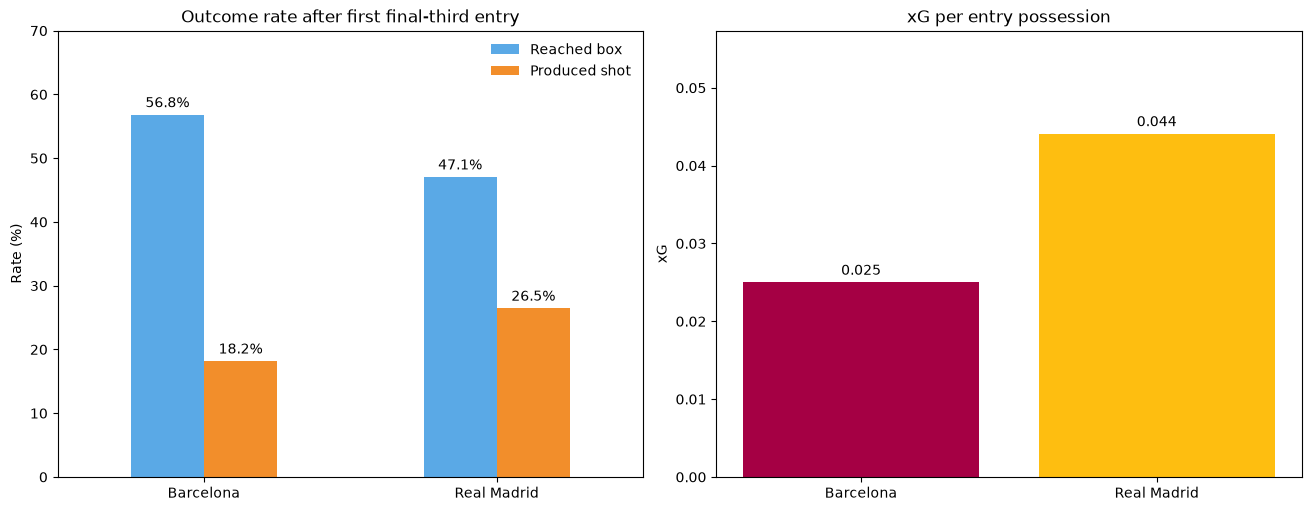

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

rate_chart = outcome_summary.loc[team_order, ["box_reach_rate", "shot_rate"]] * 100
rate_chart.columns = ["Reached box", "Produced shot"]
rate_chart.plot.bar(ax=axes[0], color=["#5AA9E6", "#F28E2B"], rot=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3)
axes[0].set(title="Outcome rate after first final-third entry", xlabel="", ylabel="Rate (%)")
axes[0].set_ylim(0, 70)
axes[0].legend(frameon=False)

xg_values = outcome_summary.loc[team_order, "xg_per_entry_possession"]
bars = axes[1].bar(team_order, xg_values, color=["#A50044", "#FEBE10"])
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set(title="xG per entry possession", xlabel="", ylabel="xG")
axes[1].set_ylim(0, xg_values.max() * 1.3)
plt.show()

## 7. 比分状态是否改变结果？

比分状态按第一次进入发生前的比分、相对于执行球队定义。Barcelona 在本场没有领先状态，Real Madrid 没有落后状态。分组后的样本很小，因此图用于解释比赛过程，不用于估计稳定转化能力。

In [12]:
state_summary = possession_outcomes.groupby(["team", "score_state"]).agg(
    entry_possessions=("possession", "size"),
    reached_box=("reached_box", "sum"),
    shot_possessions=("has_shot", "sum"),
    xg=("xg", "sum"),
)
state_summary["shot_rate"] = (
    state_summary["shot_possessions"] / state_summary["entry_possessions"]
)
state_summary["xg_per_entry_possession"] = (
    state_summary["xg"] / state_summary["entry_possessions"]
)

state_order = [
    ("Barcelona", "Level"),
    ("Barcelona", "Trailing"),
    ("Real Madrid", "Level"),
    ("Real Madrid", "Leading"),
]
state_plot = state_summary.loc[state_order].reset_index()
state_plot.round(3)

,team,score_state,entry_possessions,reached_box,shot_possessions,xg,shot_rate,xg_per_entry_possession
0,Barcelona,Level,26,16,6,0.659,0.231,0.025
1,Barcelona,Trailing,18,9,2,0.441,0.111,0.025
2,Real Madrid,Level,22,10,5,0.694,0.227,0.032
3,Real Madrid,Leading,12,6,4,0.806,0.333,0.067


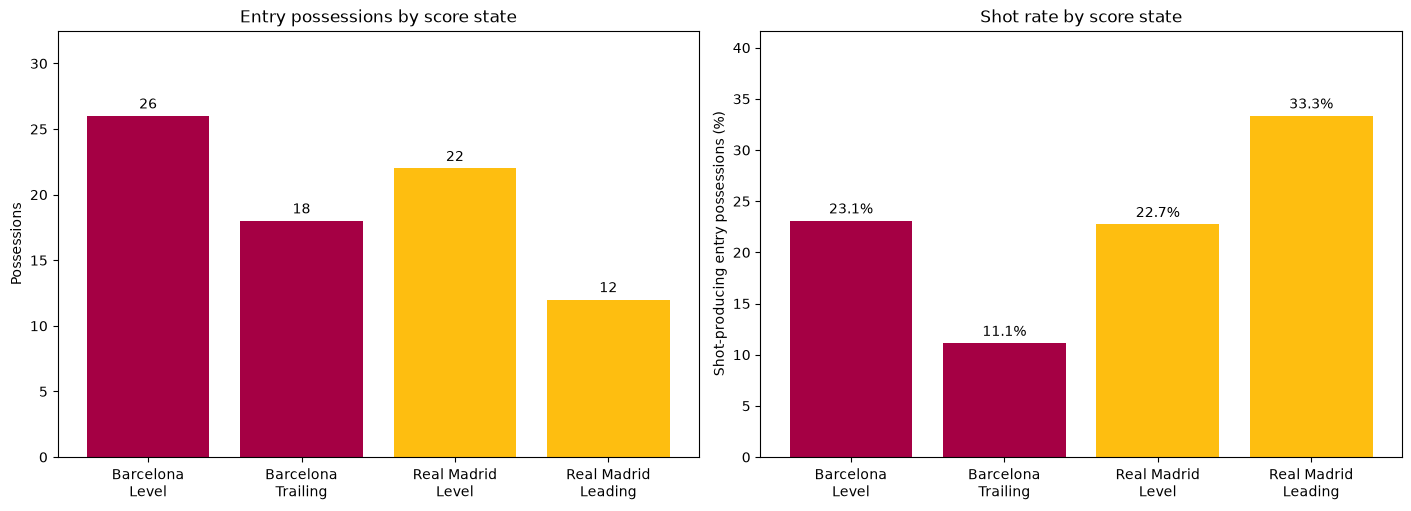

In [13]:
state_labels = [f"{team}\n{state}" for team, state in state_order]
state_colors = ["#A50044", "#A50044", "#FEBE10", "#FEBE10"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

count_bars = axes[0].bar(state_labels, state_plot["entry_possessions"], color=state_colors)
axes[0].bar_label(count_bars, padding=3)
axes[0].set(title="Entry possessions by score state", ylabel="Possessions")
axes[0].set_ylim(0, state_plot["entry_possessions"].max() * 1.25)

shot_rates = state_plot["shot_rate"] * 100
rate_bars = axes[1].bar(state_labels, shot_rates, color=state_colors)
axes[1].bar_label(rate_bars, fmt="%.1f%%", padding=3)
axes[1].set(title="Shot rate by score state", ylabel="Shot-producing entry possessions (%)")
axes[1].set_ylim(0, max(40, shot_rates.max() * 1.25))
plt.show()

## 8. 快速转换与防守恢复：先定义，再看进球

行业没有统一的秒数、传球数或推进距离定义。这里并列保留两种证据：

1. StatsBomb 的供应商标签 `play_pattern == "From Counter"`；
2. 一个透明的连续特征描述：夺回控制后多久进入三区、向前推进多快。

`possession` 有时包含短暂的对方触球，因此本节使用更窄的 **control spell**：同一个 StatsBomb possession 内，连续由同一球队完成的有效控球事件。定位球重新开始也会开启新 spell。这个代理不是新的“真相”，而是避免把一分钟的控球误称为一次快速转换。

“防线未落位”不是 open data 的现成字段。360 只能在离散事件瞬间观察画面内球员，因此下面把球门侧可见防守者人数、最近防守者距离和可见人数称为 **防守恢复代理**，不直接命名为防线已经或尚未落位。

In [14]:
THREE_SIXTY_PATH = (
    OPEN_DATA_ROOT / "data" / "three-sixty" / f"{MATCH_ID}.json"
)
with THREE_SIXTY_PATH.open() as handle:
    three_sixty = json.load(handle)

frames_by_event = {frame["event_uuid"]: frame for frame in three_sixty}
CONTROL_EVENT_TYPES = {
    "Pass",
    "Carry",
    "Dribble",
    "Shot",
    "Ball Receipt*",
    "Goal Keeper",
    "Ball Recovery",
    "Interception",
    "Duel",
    "Clearance",
}
RESTART_PASS_TYPES = {"Corner", "Free Kick", "Goal Kick", "Kick Off", "Throw-in"}
RESTART_SHOT_TYPES = {"Penalty", "Free Kick"}
OPEN_PLAY_PATTERNS = {"Regular Play", "From Counter", "From Keeper"}


def event_seconds(event: dict[str, object]) -> float:
    hours, minutes, seconds = event["timestamp"].split(":")
    return int(hours) * 3600 + int(minutes) * 60 + float(seconds)


def is_control_event(event: dict[str, object]) -> bool:
    event_type = event["type"]["name"]
    if event_type not in CONTROL_EVENT_TYPES or event.get("location") is None:
        return False
    if event_type == "Ball Receipt*" and event.get("ball_receipt", {}).get("outcome"):
        return False
    if event_type == "Interception":
        return event.get("interception", {}).get("outcome", {}).get("name") not in {
            "Lost",
            "Lost In Play",
        }
    if event_type == "Duel":
        return event.get("duel", {}).get("outcome", {}).get("name") not in {
            "Lost",
            "Lost In Play",
        }
    return True


def is_restart_event(event: dict[str, object]) -> bool:
    event_type = event["type"]["name"]
    if event_type == "Pass":
        return event.get("pass", {}).get("type", {}).get("name") in RESTART_PASS_TYPES
    if event_type == "Shot":
        return event.get("shot", {}).get("type", {}).get("name") in RESTART_SHOT_TYPES
    return False


control_spells: list[dict[str, object]] = []
current_spell: dict[str, object] | None = None
previous_control_team: str | None = None

for event in sorted(events, key=lambda item: item["index"]):
    if not is_control_event(event):
        if current_spell is not None:
            current_spell["events"].append(event)
        continue

    event_team = event["team"]["name"]
    starts_new_spell = (
        current_spell is None
        or event["possession"] != current_spell["possession"]
        or event_team != current_spell["team"]
        or is_restart_event(event)
    )
    if starts_new_spell:
        same_possession_switch = bool(
            control_spells
            and control_spells[-1]["possession"] == event["possession"]
            and control_spells[-1]["team"] != event_team
        )
        current_spell = {
            "spell_id": len(control_spells) + 1,
            "possession": event["possession"],
            "team": event_team,
            "start": event,
            "previous_control_team": previous_control_team,
            "same_possession_switch": same_possession_switch,
            "restart": is_restart_event(event),
            "events": [],
        }
        control_spells.append(current_spell)
        previous_control_team = event_team
    current_spell["events"].append(event)

assert len(control_spells) == 308
len(three_sixty), len(control_spells)

(3858, 308)

In [15]:
spell_rows: list[dict[str, object]] = []

for spell in control_spells:
    spell_events = spell["events"]
    start = spell["start"]
    team = spell["team"]
    team_events = [
        event
        for event in spell_events
        if event.get("team", {}).get("name") == team
    ]
    spell_entries = []
    for event in team_events:
        event_type = event["type"]["name"]
        if event_type not in {"Pass", "Carry"}:
            continue
        detail = event[event_type.lower()]
        end = detail.get("end_location")
        start_location = event.get("location")
        if (
            start_location
            and end
            and start_location[0] < 80 <= end[0]
            and not (event_type == "Pass" and detail.get("outcome"))
        ):
            spell_entries.append(event)

    first_entry = spell_entries[0] if spell_entries else None
    shots = [event for event in team_events if event["type"]["name"] == "Shot"]
    first_shot = shots[0] if shots else None
    goals = [
        shot for shot in shots if shot["shot"]["outcome"]["name"] == "Goal"
    ]
    start_pattern = start["play_pattern"]["name"]
    open_play_regain = bool(
        spell["previous_control_team"] not in {None, team}
        and not spell["restart"]
        and (
            spell["same_possession_switch"]
            or start_pattern in OPEN_PLAY_PATTERNS
        )
    )

    entry_context = None
    if first_entry is not None:
        context_candidates = [
            event
            for event in team_events
            if event["index"] >= first_entry["index"]
            and event.get("location")
            and event["location"][0] >= 80
            and event["id"] in frames_by_event
        ]
        entry_context = context_candidates[0] if context_candidates else None

    frame = frames_by_event.get(entry_context["id"]) if entry_context else None
    opponents = (
        [player for player in frame["freeze_frame"] if not player["teammate"]]
        if frame
        else []
    )
    ball_location = entry_context.get("location") if entry_context else None
    goalside_defenders = (
        sum(player["location"][0] >= ball_location[0] for player in opponents)
        if ball_location
        else None
    )
    nearest_defender = (
        min(
            math.dist(ball_location, player["location"])
            for player in opponents
        )
        if opponents and ball_location
        else None
    )

    entry_elapsed = None
    entry_gain = None
    if first_entry is not None:
        entry_detail = first_entry[first_entry["type"]["name"].lower()]
        entry_elapsed = (
            event_seconds(first_entry)
            + float(first_entry.get("duration", 0))
            - event_seconds(start)
        )
        entry_gain = (
            entry_detail["end_location"][0] - start["location"][0]
        )

    shot_elapsed = (
        event_seconds(first_shot) - event_seconds(start)
        if first_shot is not None
        else None
    )
    spell_rows.append(
        {
            "spell_id": spell["spell_id"],
            "possession": spell["possession"],
            "team": team,
            "start_index": start["index"],
            "start_minute": start["minute"],
            "start_type": start["type"]["name"],
            "start_pattern": start_pattern,
            "start_x": start["location"][0],
            "open_play_regain": open_play_regain,
            "provider_counter": start_pattern == "From Counter",
            "has_entry": first_entry is not None,
            "entry_event_id": first_entry["id"] if first_entry else None,
            "entry_elapsed": entry_elapsed,
            "entry_gain": entry_gain,
            "entry_speed": (
                entry_gain / entry_elapsed
                if entry_elapsed and entry_elapsed > 0
                else None
            ),
            "entry_frame": frame is not None,
            "visible_defenders": len(opponents) if frame else None,
            "goalside_defenders": goalside_defenders,
            "nearest_defender": nearest_defender,
            "has_shot": first_shot is not None,
            "shot_elapsed": shot_elapsed,
            "quick_shot_12s": bool(
                open_play_regain
                and shot_elapsed is not None
                and shot_elapsed <= 12
            ),
            "xg": sum(shot["shot"]["statsbomb_xg"] for shot in shots),
            "goal": bool(goals),
            "quick_goal_12s": bool(
                open_play_regain
                and goals
                and event_seconds(goals[0]) - event_seconds(start) <= 12
            ),
            "goal_player": goals[0]["player"]["name"] if goals else None,
            "shot_type": (
                first_shot["shot"]["type"]["name"] if first_shot else None
            ),
        }
    )

spell_profile = pd.DataFrame(spell_rows)
deep_entry_spells = spell_profile.loc[
    spell_profile["open_play_regain"]
    & spell_profile["has_entry"]
    & spell_profile["start_x"].lt(80)
].copy()

counter_baseline = spell_profile.loc[
    spell_profile["provider_counter"],
    [
        "team",
        "possession",
        "entry_elapsed",
        "entry_gain",
        "has_shot",
        "goal",
    ],
]
window_summary = pd.DataFrame(
    [
        {
            "window_seconds": window,
            "candidate_spells": int(deep_entry_spells["entry_elapsed"].le(window).sum()),
            "Barcelona": int(
                (
                    deep_entry_spells["entry_elapsed"].le(window)
                    & deep_entry_spells["team"].eq("Barcelona")
                ).sum()
            ),
            "Real Madrid": int(
                (
                    deep_entry_spells["entry_elapsed"].le(window)
                    & deep_entry_spells["team"].eq("Real Madrid")
                ).sum()
            ),
            "provider_counters": int(
                (
                    deep_entry_spells["entry_elapsed"].le(window)
                    & deep_entry_spells["provider_counter"]
                ).sum()
            ),
            "quick_shots": int(
                (
                    deep_entry_spells["entry_elapsed"].le(window)
                    & deep_entry_spells["quick_shot_12s"]
                ).sum()
            ),
        }
        for window in (5, 10, 15)
    ]
)

assert len(deep_entry_spells) == 50
assert len(counter_baseline) == 2
counter_baseline.round(2), window_summary

(          team  possession  entry_elapsed  entry_gain  has_shot   goal
 156  Barcelona          95           6.34        54.5     False  False
 305  Barcelona         176           7.12        54.3     False  False,
    window_seconds  candidate_spells  Barcelona  Real Madrid  \
 0               5                14          8            6   
 1              10                24         14           10   
 2              15                33         16           17   
 
    provider_counters  quick_shots  
 0                  0            2  
 1                  2            2  
 2                  2            2  )

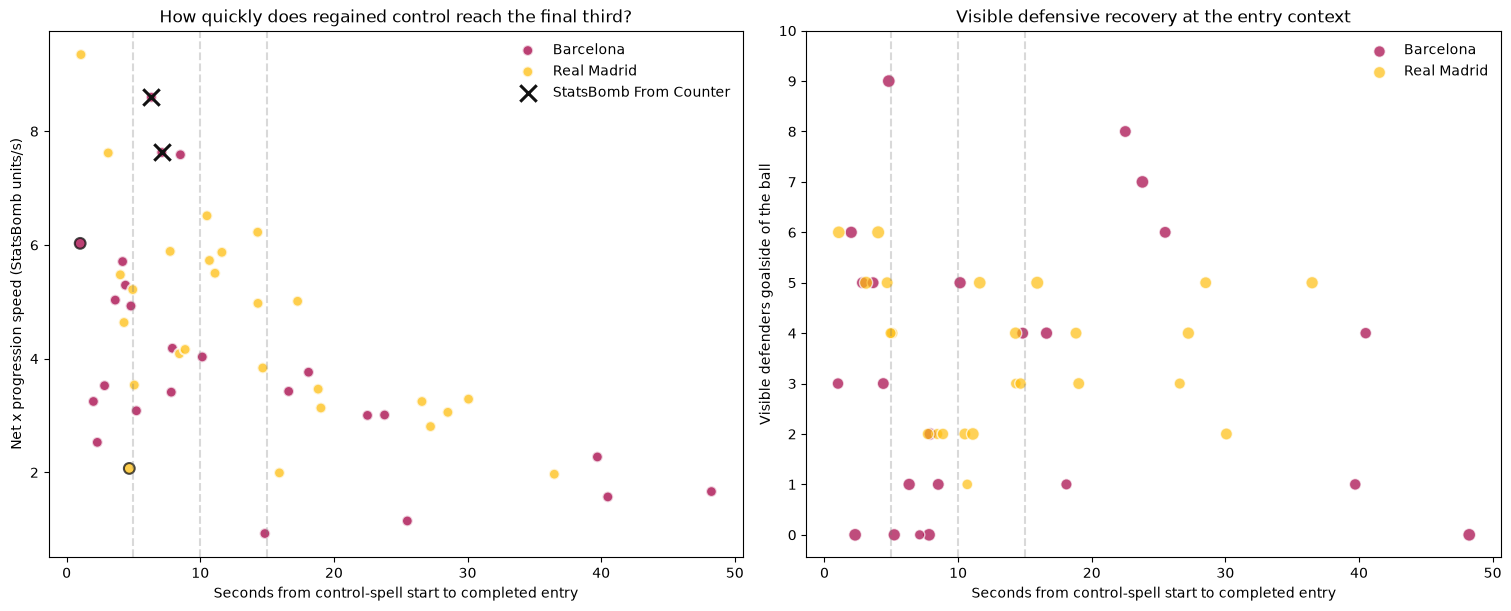

In [16]:
team_colors = {"Barcelona": "#A50044", "Real Madrid": "#FEBE10"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

for team in team_order:
    subset = deep_entry_spells.loc[deep_entry_spells["team"] == team]
    axes[0].scatter(
        subset["entry_elapsed"],
        subset["entry_speed"],
        s=60,
        color=team_colors[team],
        edgecolor=[
            "#111111" if quick else "#FFFFFF"
            for quick in subset["quick_shot_12s"]
        ],
        linewidth=1.5,
        alpha=0.75,
        label=team,
    )
    frame_subset = subset.loc[subset["entry_frame"]]
    axes[1].scatter(
        frame_subset["entry_elapsed"],
        frame_subset["goalside_defenders"],
        s=35 + frame_subset["visible_defenders"] * 5,
        color=team_colors[team],
        edgecolor="#FFFFFF",
        linewidth=1,
        alpha=0.7,
        label=team,
    )

provider_points = deep_entry_spells.loc[deep_entry_spells["provider_counter"]]
axes[0].scatter(
    provider_points["entry_elapsed"],
    provider_points["entry_speed"],
    marker="x",
    s=140,
    color="#111111",
    linewidth=2.2,
    label="StatsBomb From Counter",
)

for threshold in (5, 10, 15):
    for ax in axes:
        ax.axvline(threshold, color="#777777", linestyle="--", alpha=0.28)

axes[0].set(
    title="How quickly does regained control reach the final third?",
    xlabel="Seconds from control-spell start to completed entry",
    ylabel="Net x progression speed (StatsBomb units/s)",
)
axes[1].set(
    title="Visible defensive recovery at the entry context",
    xlabel="Seconds from control-spell start to completed entry",
    ylabel="Visible defenders goalside of the ball",
)
axes[1].set_yticks(range(0, 11))
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
plt.show()

### 怎样读这张图

- 左图越靠左表示越快进入三区，越靠上表示净向前推进越直接。虚线只是 5/10/15 秒敏感性参考，不是行业标准。
- 黑色 `×` 是 StatsBomb 标记的 `From Counter`；黑色描边表示同一 control spell 在开始后 12 秒内形成射门。
- 右图只使用存在合适 360 frame 的回合。纵轴是画面内、位于球门侧的防守者数量；点大小表示画面内可见防守者总数。

因此，右图不能把“只看到三名球门侧防守者”直接翻译成“整队只有三人回防”。它只适合筛选值得回看的场景。

In [17]:
goal_spell_audit = spell_profile.loc[
    spell_profile["goal"],
    [
        "team",
        "goal_player",
        "possession",
        "start_type",
        "start_pattern",
        "start_x",
        "open_play_regain",
        "provider_counter",
        "shot_type",
        "shot_elapsed",
        "quick_goal_12s",
    ],
].copy()
goal_spell_audit["goal_label"] = [
    "Valverde",
    "Fati",
    "Ramos",
    "Modrić",
]
goal_spell_audit[
    [
        "goal_label",
        "team",
        "start_type",
        "start_pattern",
        "start_x",
        "shot_type",
        "shot_elapsed",
        "open_play_regain",
        "provider_counter",
        "quick_goal_12s",
    ]
].round(2)

,goal_label,team,start_type,start_pattern,start_x,shot_type,shot_elapsed,open_play_regain,provider_counter,quick_goal_12s
12,Valverde,Real Madrid,Goal Keeper,From Keeper,14.8,Open Play,59.88,True,False,False
19,Fati,Barcelona,Pass,From Free Kick,32.3,Open Play,17.25,False,False,False
182,Ramos,Real Madrid,Shot,Other,107.7,Penalty,0.00,False,False,False
287,Modrić,Real Madrid,Ball Recovery,From Goal Kick,106.3,Open Play,3.34,True,False,True


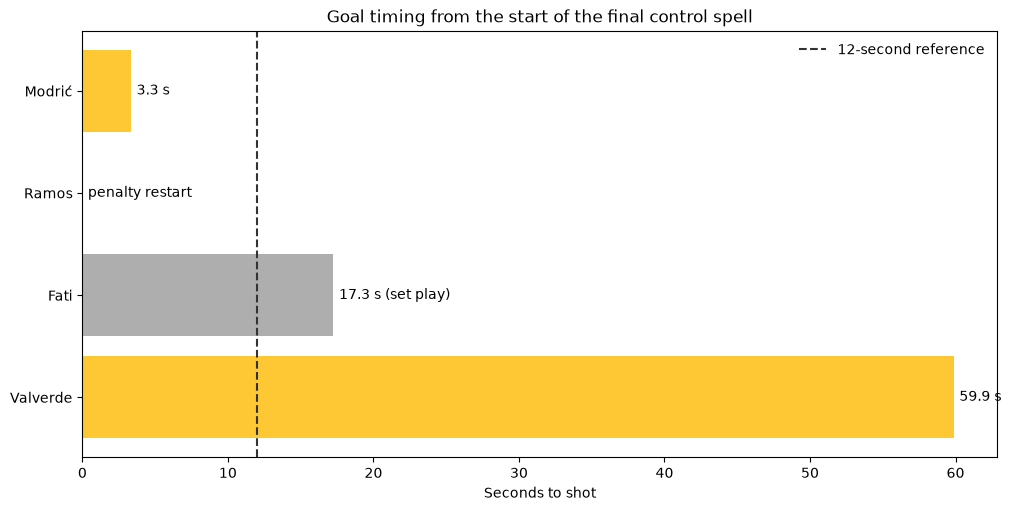

In [18]:
goal_plot = goal_spell_audit.set_index("goal_label")
goal_colors = [
    team_colors[team] if open_play else "#A0A0A0"
    for team, open_play in zip(
        goal_plot["team"], goal_plot["open_play_regain"], strict=True
    )
]
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bars = ax.barh(
    goal_plot.index,
    goal_plot["shot_elapsed"],
    color=goal_colors,
    alpha=0.85,
)
ax.axvline(12, color="#333333", linestyle="--", label="12-second reference")
goal_timing_labels = [
    "penalty restart"
    if shot_type == "Penalty"
    else f"{elapsed:.1f} s (set play)"
    if not open_play
    else f"{elapsed:.1f} s"
    for elapsed, shot_type, open_play in zip(
        goal_plot["shot_elapsed"],
        goal_plot["shot_type"],
        goal_plot["open_play_regain"],
        strict=True,
    )
]
ax.bar_label(bars, labels=goal_timing_labels, padding=4)
ax.set(
    title="Goal timing from the start of the final control spell",
    xlabel="Seconds to shot",
    ylabel="",
)
ax.legend(frameon=False)
plt.show()

### 进球对照的第一读法

- Valverde 的 control spell 从门将控制开始，但直到约 60 秒后才射门；中间已经回收并重新组织，不能把最终进球归因于最初的快速进入。
- Fati 的进球来自任意球后的进攻，不是开放比赛夺回球权。
- Ramos 是点球，单独排除。
- Modrić 的最后一个 control spell 从前场 Ball Recovery 开始，3.3 秒后射门，是四球中唯一符合“开放比赛重新夺回后迅速形成结果”的案例；它从 `x=106.3` 开始，说明只研究“跨过 x=80”会漏掉高位夺回。

这个结果是在定义和全场数据挖掘之后得到的，不是为了让某粒进球入选而调整阈值。下一张 360 图只用于观察 Modrić 回合的空间背景。

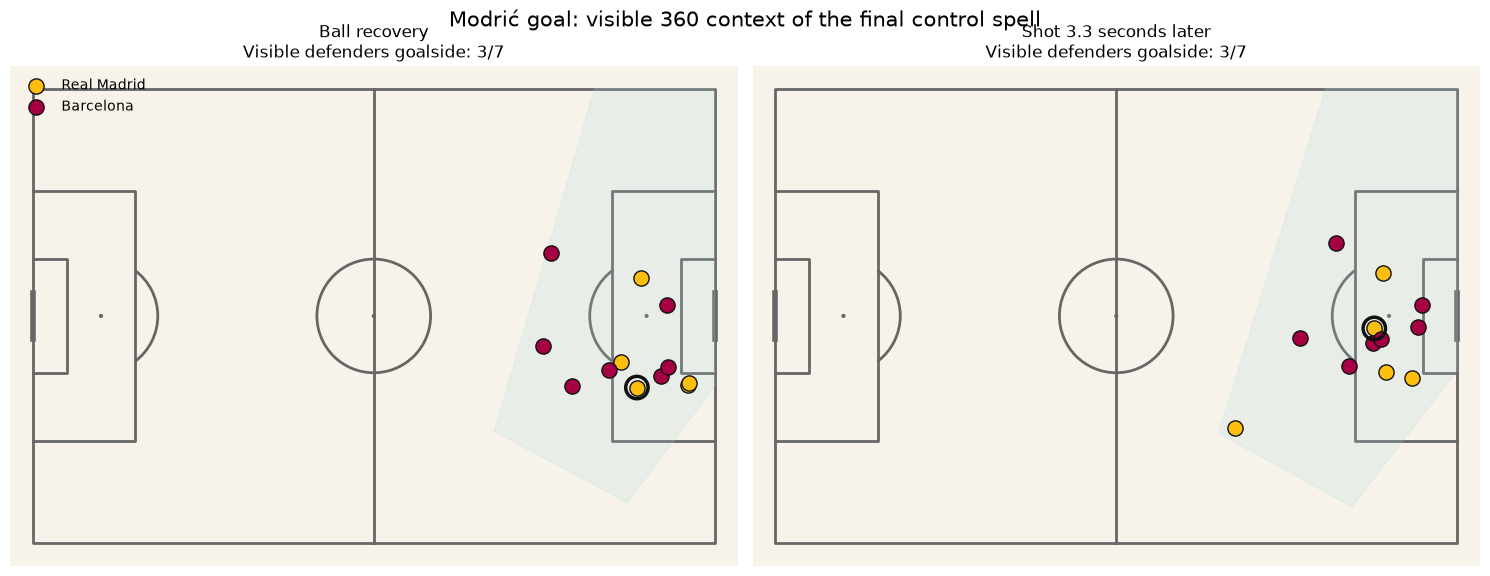

In [19]:
modric_start = next(event for event in events if event["index"] == 3984)
modric_shot = next(event for event in events if event["index"] == 3992)
modric_frames = [
    ("Ball recovery", modric_start, frames_by_event[modric_start["id"]]),
    ("Shot 3.3 seconds later", modric_shot, frames_by_event[modric_shot["id"]]),
]

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#F7F3EA",
    line_color="#666666",
)
fig, axes = pitch.draw(ncols=2, figsize=(15, 6), constrained_layout=True)

for ax, (title, event, frame) in zip(axes, modric_frames, strict=True):
    visible = frame["visible_area"]
    polygon = [
        (visible[index], visible[index + 1])
        for index in range(0, len(visible), 2)
    ]
    ax.fill(
        [point[0] for point in polygon],
        [point[1] for point in polygon],
        color="#A8DADC",
        alpha=0.18,
    )
    teammates = [player for player in frame["freeze_frame"] if player["teammate"]]
    opponents = [player for player in frame["freeze_frame"] if not player["teammate"]]
    pitch.scatter(
        [player["location"][0] for player in teammates],
        [player["location"][1] for player in teammates],
        ax=ax,
        color="#FEBE10",
        edgecolor="#111111",
        s=120,
        label="Real Madrid",
    )
    pitch.scatter(
        [player["location"][0] for player in opponents],
        [player["location"][1] for player in opponents],
        ax=ax,
        color="#A50044",
        edgecolor="#111111",
        s=120,
        label="Barcelona",
    )
    actor = next(player for player in frame["freeze_frame"] if player["actor"])
    pitch.scatter(
        actor["location"][0],
        actor["location"][1],
        ax=ax,
        facecolor="none",
        edgecolor="#111111",
        s=260,
        linewidth=2.5,
    )
    ball_x = event["location"][0]
    goalside_count = sum(
        player["location"][0] >= ball_x for player in opponents
    )
    ax.set_title(
        f"{title}\nVisible defenders goalside: {goalside_count}/{len(opponents)}"
    )

axes[0].legend(loc="upper left", frameon=False)
fig.suptitle("Modrić goal: visible 360 context of the final control spell", fontsize=15)
plt.show()

## 当前读法与证据边界

- **数据事实：** 原始文件包含 4,213 个 events 和 3,858 个 360 frames；本课定义筛出 117 次进入。
- **指标结果：** 117次事件属于78个至少成功进入一次三区的 possession。Barcelona 有44个，25个后续到达禁区、8个形成射门、产生1.101 xG；Real Madrid 有34个，16个到达禁区、9个形成射门、产生1.500 xG。
- **转换定义：** StatsBomb 只标出2个 `From Counter` control spells，均属于 Barcelona 且没有形成射门。透明代理则保留连续的进入用时和推进速度，并展示 5/10/15 秒敏感性，不宣称存在统一行业阈值。
- **进球对照：** 四个进球中，只有 Modrić 的最终 control spell 是开放比赛重新夺回后12秒内形成进球；它从进攻三区内开始。Valverde 的最终射门距离 spell 起点约60秒，Fati 来自任意球，Ramos 是点球。
- **足球解释：** 本场“Real Madrid 的进入转化更高”不能简单解释成更多 StatsBomb 反击。更具体的待验证机制是：个别高位重新夺回是否让 Barcelona 没有时间恢复防守结构。
- **证据边界：** 360 图只包含 `visible_area` 内的离散快照。球门侧可见防守人数与最近防守者距离是防守恢复代理，不证明整条防线是否落位，也不能替代视频。

当前结果仍包含不同 `play_pattern`。直接界外球是 `pass_type=Throw-in`，而界外球发起的后续进攻是 `play_pattern=From Throw In`；二者不能混为一谈。禁区到达定义为同队后续事件的起点，或成功 Pass/Carry 的终点位于禁区内；它不是精确识别一次穿过禁区边界的动作。

## 练习

1. 把 `entries` 限制为 `play_pattern == "Regular Play"`，重新生成球队汇总。
2. 将快速进入参考窗从 10 秒改为 5 秒和 15 秒，观察候选回合如何变化；说明为什么这不是在寻找唯一正确阈值。
3. 从散点图中各选一个快速且球门侧防守者较少、以及快速但球门侧防守者较多的回合，回看事件序列和 360：同样的进入速度是否代表相同的防守环境？

In [20]:
regular_play_entries = entries.loc[entries["play_pattern"] == "Regular Play"]
pd.crosstab(regular_play_entries["team"], regular_play_entries["method"]).reindex(
    columns=["Pass", "Carry"], fill_value=0
)

method,Pass,Carry
team,,
Barcelona,19,13
Real Madrid,18,13
